# Court Vision Mapping (CVM)

Train a YOLO26-pose model on basketball court keypoints, then use it to project on-court player positions onto a top-down court diagram.

The player detection model is trained separately): here we just load his weights and consume them.

## 1. Setup
Installs and imports. Run once per kernel session.

In [1]:
# Install pinned versions and pull the basketball branch of roboflow/sports
# for court geometry and team clustering.
%pip install torchvision==0.23
%pip install -q ultralytics supervision pyyaml
%pip install --no-cache-dir -q "git+https://github.com/roboflow/sports.git@feat/basketball"

# Standard libs and CV utilities used throughout the notebook.
import os
import yaml
import cv2
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm

import supervision as sv
from ultralytics import YOLO

# Court geometry, drawing helpers, homography wrapper, team classifier,
# and the path-cleaning function. All from the basketball branch of sports.
from sports.basketball import (
    CourtConfiguration,
    League,
    draw_court,
    draw_points_on_court,
    draw_paths_on_court,
)
from sports.basketball.config import MeasurementUnit
from sports.common.view import ViewTransformer
from sports.common.team import TeamClassifier
from sports.common.path import clean_paths

SEED = 45
HOME = Path.cwd()

# Class indices in Abdo's six-class player detector. Class 3 is what we keep;
# the others are ball, ball-in-basket, number, referee, rim.
PLAYER_CLASS_ID = 3

# Two visual colours for the team clusters. KMeans assigns 0/1 randomly so
# the pairing of colour to real team can flip between runs of the notebook.
TEAM_PALETTE = [sv.Color.from_hex("#2563eb"), sv.Color.from_hex("#ea580c")]


  Using cached torchvision-0.23.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.1 kB)


Using cached torchvision-0.23.0-cp312-cp312-manylinux_2_28_x86_64.whl (8.6 MB)


  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.24.0


    Uninstalling torchvision-0.24.0:
      Successfully uninstalled torchvision-0.24.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.3.0 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
sagemaker-serve 1.10.0 requires onnxruntime, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


E0000 00:00:1780319385.411481     444 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780319385.423642     444 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780319385.598045     444 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780319385.598079     444 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780319385.598082     444 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780319385.598084     444 computation_placer.cc:177] computation placer already registered. Please check linka

## 2. Dataset preparation

The court dataset is a keypoint/pose dataset: 33 vertices per image. The shipped `data.yaml` uses relative paths, so we rewrite it with absolute paths to make Ultralytics resilient to the current working directory.

In [2]:
# Rewrite the dataset's data.yaml with absolute paths so Ultralytics finds
# the train/valid/test splits regardless of the current working directory.
CVM_root = Path("Data/Datasets/basketball-court-detection-2.v1-1.yolov8/").resolve()
src_yaml_path = CVM_root / "data.yaml"

with open(src_yaml_path) as f:
    cfg = yaml.safe_load(f)

cfg["path"] = str(CVM_root)
cfg["train"] = str(CVM_root / "train" / "images")
cfg["val"] = str(CVM_root / "valid" / "images")
cfg["test"] = str(CVM_root /  "test" / "images")

# Save the patched yaml next to the notebook for the training cell to consume.
updated_yaml_path = Path("cvm_data.yaml").resolve()
with open(updated_yaml_path, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print(f"Wrote {updated_yaml_path}")
print(f"  train: {cfg['train']}")
print(f"  val:   {cfg['val']}")
print(f"  test:  {cfg['test']}")
print(f"  nc: {cfg['nc']}  names: {cfg['names']}  kpt_shape: {cfg.get('kpt_shape')}")


Wrote /home/sagemaker-user/DLCNN_A3/cvm_data.yaml
  train: /home/sagemaker-user/DLCNN_A3/Data/Datasets/basketball-court-detection-2.v1-1.yolov8/train/images
  val:   /home/sagemaker-user/DLCNN_A3/Data/Datasets/basketball-court-detection-2.v1-1.yolov8/valid/images
  test:  /home/sagemaker-user/DLCNN_A3/Data/Datasets/basketball-court-detection-2.v1-1.yolov8/test/images
  nc: 1  names: ['court']  kpt_shape: [33, 3]


## 3. Train the CVM model,

Fine-tune `yolo26n-pose.pt` on the 33-vertex court dataset. Weights auto-download on first use.

In [3]:
# Load the pose variant of YOLO26n, pre-trained on COCO Pose. The training
# step below re-trains the keypoint head for our 33 court keypoints.
CVM_model = YOLO("yolo26n-pose.pt")
CVM_model.info()


YOLO26n-pose summary: 363 layers, 3,679,464 parameters, 0 gradients, 10.3 GFLOPs


(363, 3679464, 0, 10.318528)

In [4]:
# Fine-tune the pose model on the court keypoint dataset.
# patience=60: early-stop if validation fitness does not improve for 60 epochs.
# imgsz=640: standard YOLO input size.
# batch=8: fits a single GPU comfortably.
# seed and deterministic=True make the run reproducible.
CVM_results = CVM_model.train(
    data=str(updated_yaml_path),
    epochs=500,
    imgsz=640,
    batch=8,
    project="runs",
    name="CVM",
    exist_ok=True,
    deterministic=True,
    seed=SEED,
    plots=True,
    patience=60,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=4,
)


Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.8.0 CUDA:0 (Tesla T4, 14913MiB)
Overriding model.yaml kpt_shape=[17, 3] with kpt_shape=[33, 3]
YOLO26n-pose summary: 363 layers, 5,526,984 parameters, 5,526,984 gradients, 18.9 GFLOPs
Transferred 795/879 items from pretrained weights
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /home/sagemaker-user/DLCNN_A3/runs/pose/runs/CVM
Starting training for 500 epochs...
                   all        124        124          1      0.991      0.995      0.595          0          0          0          0
                   all        124        124      0.983      0.992      0.995      0.556      0.272      0.274      0.102     0.0158
                   all        124        124      0.993      0.992      0.995      0.598      0.218      0.218      0.083     0.0178
                   all        124        124      0.989      0.968      0.994      0.694       0.52      0.508      0.292     0.0752
                   all      

## 4. Single-frame keypoint sanity check

Load the best weights and overlay the detected court vertices on the first frame of a sample clip. Vertices below the confidence floor get zeroed out so the annotator skips them.

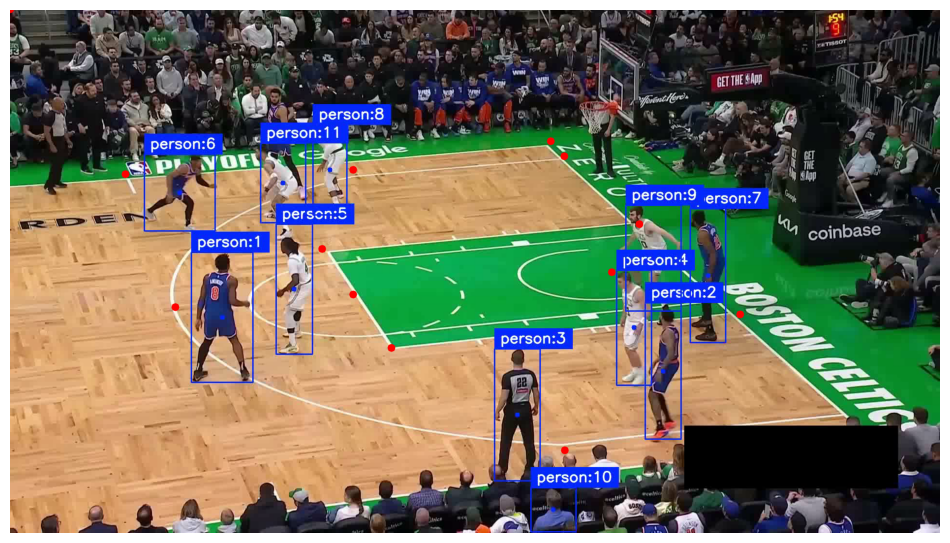

In [5]:
# Sanity check: run the trained CVM model on a single frame from a test
# video and overlay the keypoints the model is confident about.
CVM_MODEL_PATH = "runs/pose/runs/CVM/weights/best.pt"
SOURCE_VIDEO_PATH = "Data/object-tracking.mp4"

# CVM_CONF: model-level confidence (does it emit any keypoints at all).
# CVM_ANCHOR_CONF: per-keypoint confidence (only trust a vertex above this).
CVM_CONF = 0.3
CVM_ANCHOR_CONF = 0.5

CVM_model = YOLO(CVM_MODEL_PATH)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = CVM_model.predict(frame, conf=CVM_CONF, verbose=False)[0]
key_points = sv.KeyPoints.from_ultralytics(result)

# Zero out low-confidence vertices. VertexAnnotator treats (0, 0) as
# 'not drawn', so this is a simple way to filter the visualisation.
confidence_mask = key_points.confidence > CVM_ANCHOR_CONF
filtered_xy = np.where(confidence_mask[..., None], key_points.xy, 0)
key_points = sv.KeyPoints(xy=filtered_xy, confidence=key_points.confidence)

# Draw the surviving vertices in red on the original frame.
vertex_annotator = sv.VertexAnnotator(color=sv.Color.RED, radius=8)
annotated_frame = vertex_annotator.annotate(scene=frame.copy(), key_points=key_points)
sv.plot_image(annotated_frame)


## 5. Fit the team classifier

Sample player crops from across the video and fit an unsupervised classifier. It learns two jersey clusters — works on any game without knowing which specific teams are playing.

In [6]:
# Load Abdo's six-class player detector (the bridge uses the same weights).
PLAYER_MODEL_PATH = "runs_abdo/basketball/yolo26s_960/weights/best.pt"
PLAYER_CONF = 0.25
PLAYER_IOU = 0.5
FIT_STRIDE = 30  # sample one frame every 30 to gather diverse jersey crops

PLAYER_DETECTION_MODEL = YOLO(PLAYER_MODEL_PATH)

# Walk the video at the stride, detect players, and collect tight torso
# crops for clustering. factor=0.5 shrinks the box toward its centre so
# each crop is mostly jersey rather than court background.
crops = []
fit_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, stride=FIT_STRIDE)
for frame in tqdm(fit_generator, desc="collecting jersey crops"):
    result = PLAYER_DETECTION_MODEL.predict(frame, conf=PLAYER_CONF, iou=PLAYER_IOU, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    detections = detections[detections.class_id == PLAYER_CLASS_ID]
    boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.5)
    crops.extend([sv.crop_image(frame, box) for box in boxes])

print(f"Collected {len(crops)} player crops for fitting.")

# TeamClassifier under the hood: SigLIP image embeddings + KMeans(k=2).
# Unsupervised so it works on any two-team game, no labels needed.
team_classifier = TeamClassifier(device="cuda" if torch.cuda.is_available() else "cpu")
team_classifier.fit(crops)
print("Team classifier fitted.")


Collected 70 player crops for fitting.
Team classifier fitted.


collecting jersey crops: 0it [00:00, ?it/s]
collecting jersey crops: 1it [00:00,  3.96it/s]
collecting jersey crops: 3it [00:00,  7.33it/s]
collecting jersey crops: 5it [00:00,  8.92it/s]
collecting jersey crops: 7it [00:00,  9.49it/s]
collecting jersey crops: 7it [00:00,  8.43it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  2.28it/s]
Embedding extraction: 2it [00:00,  2.47it/s]
Embedding extraction: 3it [00:00,  3.31it/s]


## 6. Single-frame player  court mapping

Detect players (class 3 only), classify each by team, fit a homography from the visible court vertices, project each player's bottom-center anchor onto the top-down court, and drop anything that lands outside the court rectangle.

9 players after dedup



Embedding extraction: 0it [00:00, ?it/s]


Embedding extraction: 1it [00:00, 10.21it/s]

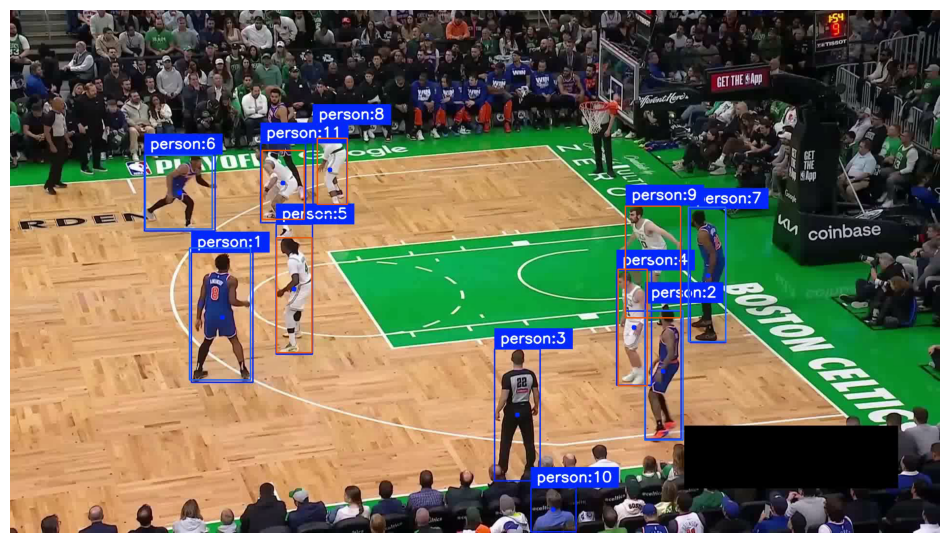

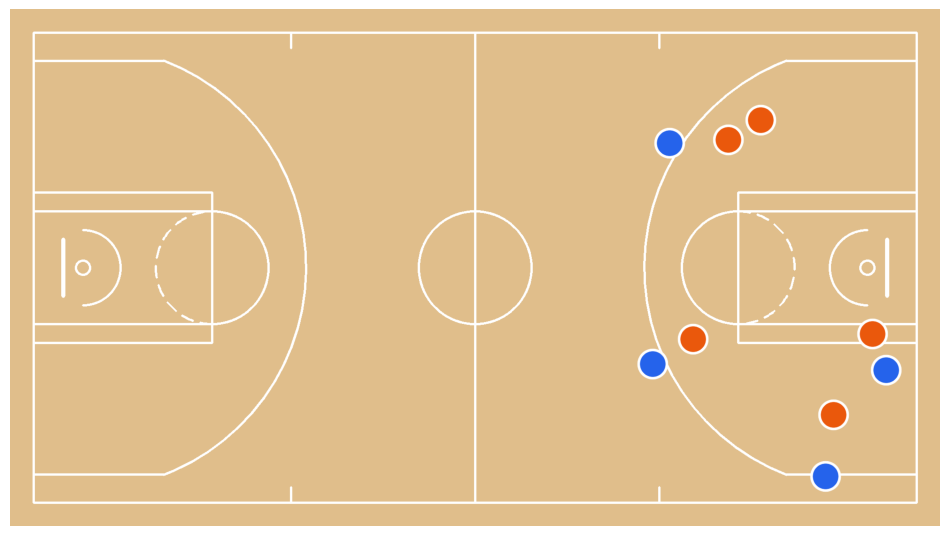

In [30]:
# NBA full-court geometry. Coords are kept in feet so distances are easy
# to reason about. COURT_MARGIN absorbs small homography wobble.
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
COURT_W, COURT_H = 94, 50
COURT_MARGIN = 2

START_FRAME = 0
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=START_FRAME)
frame = next(frame_generator)

# Run player detection, keep only the player class (drops refs/ball/rim/numbers).
# NMS with class_agnostic=False also dedupes overlapping boxes for the same player.
result = PLAYER_DETECTION_MODEL.predict(frame, conf=.2, iou=PLAYER_IOU, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)
detections = detections[detections.class_id == PLAYER_CLASS_ID]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)
detections = detections[detections.class_id == PLAYER_CLASS_ID]
detections = detections.with_nms(threshold=0.5, class_agnostic=False)
print(f"{len(detections)} players after dedup")

# Predict cluster (0 or 1) per player from their torso crop.
crops = [sv.crop_image(frame, box) for box in sv.scale_boxes(xyxy=detections.xyxy, factor=0.5)]
teams = np.array(team_classifier.predict(crops)) if crops else np.array([], dtype=int)

# Draw boxes coloured by cluster.
team_palette = sv.ColorPalette(TEAM_PALETTE)
box_annotator = sv.BoxAnnotator(color=team_palette, thickness=2, color_lookup=sv.ColorLookup.INDEX)
annotated_frame = box_annotator.annotate(
    scene=frame.copy(), detections=detections, custom_color_lookup=teams,
)
sv.plot_image(annotated_frame)

# Court keypoint detection. confidence is None when the model finds no court
# on the frame (replay cuts, crowd shots, sideline angles).
result = CVM_model.predict(frame, conf=CVM_CONF, verbose=False)[0]
key_points = sv.KeyPoints.from_ultralytics(result)

if key_points.confidence is not None and len(detections) > 0:
    landmarks_mask = key_points.confidence[0] > CVM_ANCHOR_CONF
else:
    landmarks_mask = np.zeros(0, dtype=bool)

# Need 4+ vertices to fit a homography. cv2.findHomography is wrapped by
# ViewTransformer; the result maps image pixels to court feet.
if np.count_nonzero(landmarks_mask) >= 4:
    court_landmarks = np.array(config.vertices)[landmarks_mask]
    frame_landmarks = key_points[:, landmarks_mask].xy[0]
    transformer = ViewTransformer(source=frame_landmarks, target=court_landmarks)

    # Project each player's feet (bottom-center of their box) to court coords.
    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
    court_xy = transformer.transform_points(points=frame_xy)

    # Drop projections that landed outside the court rectangle (benchwarmers,
    # sideline staff, homography wobble).
    on_court = (
        (court_xy[:, 0] >= -COURT_MARGIN) & (court_xy[:, 0] <= COURT_W + COURT_MARGIN) &
        (court_xy[:, 1] >= -COURT_MARGIN) & (court_xy[:, 1] <= COURT_H + COURT_MARGIN)
    )
    court_xy = court_xy[on_court]
    teams_on_court = teams[on_court]

    # Draw the top-down court and overlay each team's surviving players.
    court = draw_court(config=config)
    for team_id, colour in enumerate(TEAM_PALETTE):
        team_xy = court_xy[teams_on_court == team_id]
        if len(team_xy) > 0:
            court = draw_points_on_court(config=config, xy=team_xy, fill_color=colour, court=court)
    sv.plot_image(court)
else:
    print(f"Only {np.count_nonzero(landmarks_mask)} vertices above {CVM_ANCHOR_CONF} or no players, skipping homography.")


## 7. Full-video player  court mapping

Walk every frame, run the same player → team → homography → court pipeline as above, and accumulate per-frame (positions, team IDs).

In [8]:
# Per-frame projection across the whole video. The player detector runs in
# tracking mode so each detection carries a stable tracker_id that survives
# occlusions, which is what makes the per-track trajectories meaningful.
video_xy = []
video_teams = []
video_tracker_ids = []

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

for frame in tqdm(frame_generator, desc="projecting frames"):
    # Player detection + ByteTrack (Ultralytics default). persist=True keeps
    # tracker state between frames.
    result = PLAYER_DETECTION_MODEL.track(
        frame, persist=True, conf=PLAYER_CONF, iou=PLAYER_IOU, verbose=False
    )[0]
    detections = sv.Detections.from_ultralytics(result)
    detections = detections[detections.class_id == PLAYER_CLASS_ID]

    # Court keypoint detection (used for the per-frame homography below).
    cvm_result = CVM_model.predict(frame, conf=CVM_CONF, verbose=False)[0]
    key_points = sv.KeyPoints.from_ultralytics(cvm_result)

    no_court = key_points.confidence is None
    no_players = len(detections) == 0 or detections.tracker_id is None

    # Skip frames with nothing to project. Empty rows keep the output arrays
    # time-aligned with the source video for the rendering step.
    if no_court or no_players:
        video_xy.append(np.zeros((0, 2)))
        video_teams.append(np.zeros((0,), dtype=int))
        video_tracker_ids.append(np.zeros((0,), dtype=int))
        continue

    landmarks_mask = key_points.confidence[0] > CVM_ANCHOR_CONF
    if np.count_nonzero(landmarks_mask) < 4:
        video_xy.append(np.zeros((0, 2)))
        video_teams.append(np.zeros((0,), dtype=int))
        video_tracker_ids.append(np.zeros((0,), dtype=int))
        continue

    # Cluster prediction per player.
    crops = [sv.crop_image(frame, box) for box in sv.scale_boxes(xyxy=detections.xyxy, factor=0.5)]
    teams = np.array(team_classifier.predict(crops))

    # Per-frame homography and projection to court coords.
    court_landmarks = np.array(config.vertices)[landmarks_mask]
    frame_landmarks = key_points[:, landmarks_mask].xy[0]
    transformer = ViewTransformer(source=frame_landmarks, target=court_landmarks)
    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
    court_xy = transformer.transform_points(points=frame_xy)

    # Drop points outside the court rectangle.
    on_court = (
        (court_xy[:, 0] >= -COURT_MARGIN) & (court_xy[:, 0] <= COURT_W + COURT_MARGIN) &
        (court_xy[:, 1] >= -COURT_MARGIN) & (court_xy[:, 1] <= COURT_H + COURT_MARGIN)
    )
    video_xy.append(court_xy[on_court])
    video_teams.append(teams[on_court])
    video_tracker_ids.append(detections.tracker_id[on_court])

unique_tracks = sorted({int(t) for row in video_tracker_ids for t in row})
print(f"Projected {len(video_xy)} frames across {len(unique_tracks)} unique tracks.")


requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /opt/conda
Resolved 2 packages in 399ms
Prepared 1 package in 28ms
Installed 1 package in 22ms
 + lap==0.5.13
requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect
Projected 189 frames across 29 unique tracks.


In [9]:
# Render the raw (uncleaned) projections to an MP4. Each frame is the empty
# court diagram with one dot per on-court player, coloured by team.
source_path = Path(SOURCE_VIDEO_PATH)
TARGET_VIDEO_PATH = HOME / f"{source_path.stem}-map{source_path.suffix}"

# Match the output frame size to the court diagram so dots line up.
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
sample_court = draw_court(config=config)
video_info.height, video_info.width = sample_court.shape[:2]

with sv.VideoSink(str(TARGET_VIDEO_PATH), video_info) as sink:
    for frame_xy, frame_teams in tqdm(zip(video_xy, video_teams), total=len(video_xy), desc="writing video"):
        court = draw_court(config=config)
        for team_id, colour in enumerate(TEAM_PALETTE):
            team_xy = frame_xy[frame_teams == team_id]
            if len(team_xy) > 0:
                court = draw_points_on_court(config=config, xy=team_xy, fill_color=colour, court=court)
        sink.write_frame(court)

print(f"Wrote {TARGET_VIDEO_PATH}")


Wrote /home/sagemaker-user/DLCNN_A3/object-tracking-map.mp4


writing video: 100%|██████████| 189/189 [00:07<00:00, 26.10it/s]


## 8. Clean and smooth movement paths

Two things go wrong with raw projections:
1. **Teleports** — a misdetected vertex flips the homography for a few frames, sending the projected point hundreds of feet across the court.
2. **Jitter** — frame-to-frame keypoint noise produces a shaky path even when the homography is roughly right.

`sports.common.path.clean_paths` (imported in the setup cell) flags short bad runs using MAD-based speed outliers, interpolates over them, then smooths with a Savitzky–Golay filter. It expects fixed-width tracks, so we first stack each frame's variable-length projections into a `(T, N, 2)` array with NaN padding.

In [ ]:
def stack_tracks(per_frame_xy, num_tracks):
    """Pad per-frame projections into a fixed (T, N, 2) array, NaN for
    frames where a track was not observed. Required input shape for clean_paths."""
    T = len(per_frame_xy)
    out = np.full((T, num_tracks, 2), np.nan, dtype=float)
    for t, xy in enumerate(per_frame_xy):
        n = min(len(xy), num_tracks)
        if n:
            out[t, :n] = xy[:n]
    return out


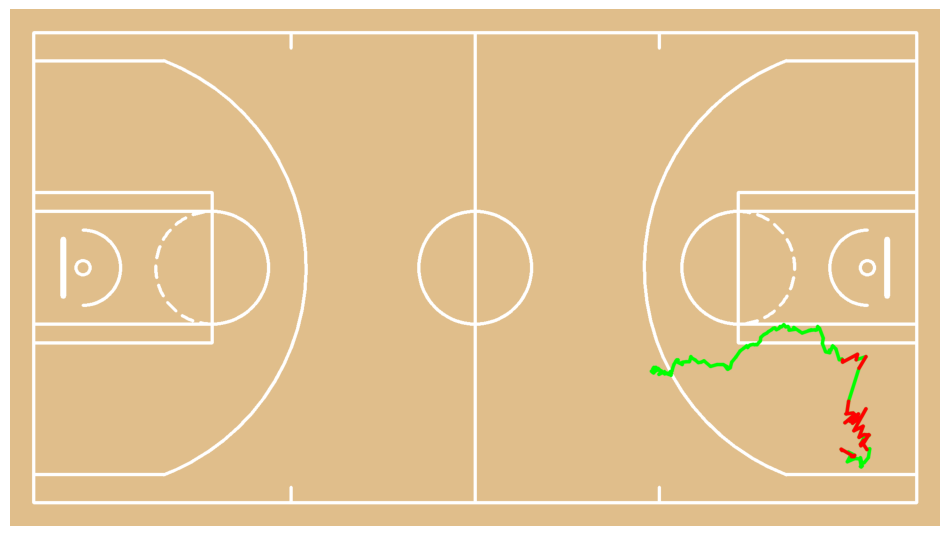

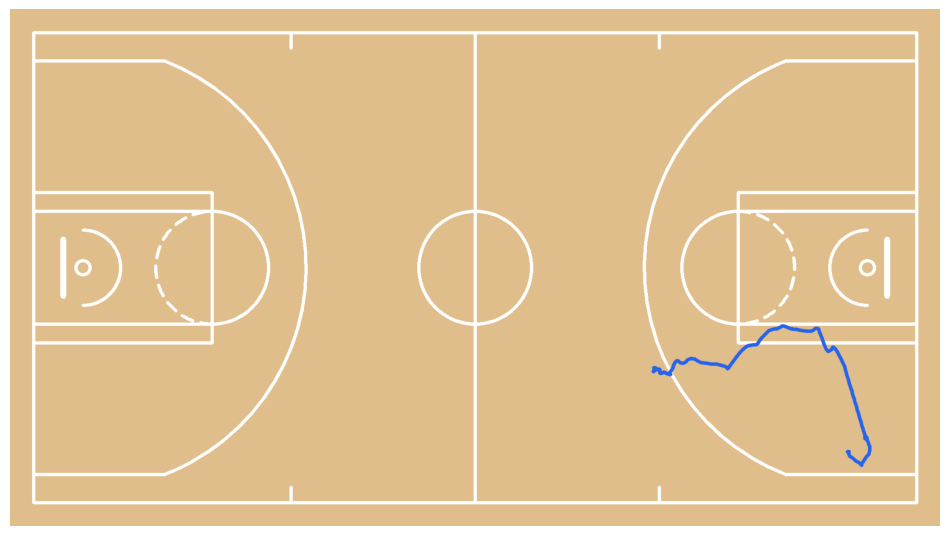

In [11]:
# Reshape variable-length per-frame lists into a fixed (T, N, 2) array where
# each column is one tracker_id. NaN marks frames the track was not seen.
T = len(video_xy)
all_track_ids = sorted({int(t) for row in video_tracker_ids for t in row})
track_id_to_col = {tid: i for i, tid in enumerate(all_track_ids)}
N = len(all_track_ids)

stacked_xy = np.full((T, N, 2), np.nan, dtype=float)
stacked_teams = np.full((T, N), -1, dtype=int)
for t in range(T):
    for xy, team, tid in zip(video_xy[t], video_teams[t], video_tracker_ids[t]):
        col = track_id_to_col[int(tid)]
        stacked_xy[t, col] = xy
        stacked_teams[t, col] = int(team)

# clean_paths is from sports.common.path. jump_sigma rejects MAD outliers,
# then a Savitzky-Golay filter (smooth_window=9, smooth_poly=2) smooths jitter.
cleaned_xy, edited_mask = clean_paths(
    stacked_xy,
    jump_sigma=3.5,
    min_jump_dist=0.6,
    max_jump_run=18,
    pad_around_runs=2,
    smooth_window=9,
    smooth_poly=2,
)

# Per-track dominant team (mode across the frames where a team was assigned).
def dominant_team(col):
    valid = col[col >= 0]
    if valid.size == 0:
        return 0
    vals, counts = np.unique(valid, return_counts=True)
    return int(vals[counts.argmax()])

track_team = np.array([dominant_team(stacked_teams[:, n]) for n in range(N)])

# Visualisation: for track 0, draw the raw path in green and overlay the
# segments clean_paths flagged as anomalous in red.
def split_true_runs(mask, coords):
    mask = mask.squeeze()
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return []
    splits = np.where(np.diff(idx) > 1)[0] + 1
    return [coords[g] for g in np.split(idx, splits)]


raw_track = stacked_xy[:, 0, :]
court = draw_paths_on_court(
    config=config,
    paths=[raw_track[~np.isnan(raw_track).any(axis=1)]],
    color=sv.Color.GREEN,
)
court = draw_paths_on_court(
    config=config,
    paths=split_true_runs(edited_mask[:, 0], raw_track),
    color=sv.Color.RED,
    court=court,
)
sv.plot_image(court)

# Final cleaned + smoothed trajectory for the same track.
court = draw_paths_on_court(
    config=config,
    paths=[cleaned_xy[:, 0, :]],
    color=TEAM_PALETTE[track_team[0]],
)
sv.plot_image(court)


### Render cleaned tracks to video

In [12]:
# Render the cleaned trajectories to an MP4 and re-encode to H.264 so it
# plays in a browser. ffmpeg is invoked via imageio_ffmpeg so we do not
# rely on a system install of ffmpeg.
import os, imageio_ffmpeg
FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()

ret = os.system(
    f"{FFMPEG} -y -loglevel error -i {TARGET_CLEAN_PATH} "
    f"-vcodec libx264 -crf 28 {TARGET_CLEAN_COMPRESSED_PATH}"
)
print(f"Wrote {TARGET_CLEAN_COMPRESSED_PATH}" if ret == 0
      else "ffmpeg failed, compressed file NOT written")%%!
TARGET_CLEAN_PATH = HOME / f"{source_path.stem}-map-cleaned{source_path.suffix}"
TARGET_CLEAN_COMPRESSED_PATH = HOME / f"{TARGET_CLEAN_PATH.stem}-compressed.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_info.height, video_info.width = draw_court(config=config).shape[:2]

with sv.VideoSink(str(TARGET_CLEAN_PATH), video_info) as sink:
    for t in tqdm(range(cleaned_xy.shape[0]), desc="writing cleaned video"):
        frame_xy = cleaned_xy[t]
        valid = ~np.isnan(frame_xy).any(axis=1)
        court = draw_court(config=config)
        for team_id, colour in enumerate(TEAM_PALETTE):
            team_mask = valid & (track_team == team_id)
            if team_mask.any():
                court = draw_points_on_court(
                    config=config,
                    xy=frame_xy[team_mask],
                    fill_color=colour,
                    court=court,
                )
        sink.write_frame(court)

!ffmpeg -y -loglevel error -i {TARGET_CLEAN_PATH} -vcodec libx264 -crf 28 {TARGET_CLEAN_COMPRESSED_PATH}
print(f"Wrote {TARGET_CLEAN_COMPRESSED_PATH}")


Wrote /home/sagemaker-user/DLCNN_A3/object-tracking-map-cleaned-compressed.mp4


writing cleaned video: 100%|██████████| 189/189 [00:07<00:00, 24.44it/s]


In [13]:
# Load the training results CSV and print the final-epoch validation metrics
# (mAP@50, mAP@50-95, etc.). Quick proof that training converged.
import pandas as pd
df = pd.read_csv("runs/pose/runs/CVM/results.csv")
df.columns = df.columns.str.strip()
print("last epoch:", int(df["epoch"].iloc[-1]))
print(df[[c for c in df.columns if "metrics" in c]].iloc[-1].to_string())


last epoch: 105
metrics/precision(B)    0.99184
metrics/recall(B)       0.97982
metrics/mAP50(B)        0.99363
metrics/mAP50-95(B)     0.88651
metrics/precision(P)    0.95919
metrics/recall(P)       0.94767
metrics/mAP50(P)        0.96219
metrics/mAP50-95(P)     0.81113
